In [1]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


In [3]:
import pandas as pd
import re
SEED = 42 # Define a seed for reproducibility

# To keep runtime manageable, use a subset of IMDB
train_raw = load_dataset("imdb", split="train")
test_raw  = load_dataset("imdb", split="test")

train_subset = train_raw.shuffle(seed=SEED).select(range(6000))
test_subset  = test_raw.shuffle(seed=SEED).select(range(2000))

train_df = pd.DataFrame(train_subset)
test_df = pd.DataFrame(test_subset)

train_df = train_df.rename(columns={"text": "review", "label": "label"})
test_df = test_df.rename(columns={"text": "review", "label": "label"})

train_df["sentiment"] = train_df["label"].map({0: "negative", 1: "positive"})
test_df["sentiment"] = test_df["label"].map({0: "negative", 1: "positive"})

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label"]
)

print("PART C1: Dataset Information\n")
print("Train size      :", len(train_df))
print("Validation size :", len(val_df))
print("Test size       :", len(test_df))

print("\nTrain class distribution:")
print(train_df["sentiment"].value_counts())

def simple_length(text):
    return len(re.findall(r"[a-zA-Z']+", text.lower()))

avg_len = train_df["review"].apply(simple_length).mean()
print(f"\nAverage review length in tokens (train subset): {avg_len:.2f}")

print("\n2 positive examples:")
for text in train_df[train_df["label"] == 1]["review"].head(2):
    print("- ", text[:300].replace("\n", " "), "...")
    print()

print("\n2 negative examples:")
for text in train_df[train_df["label"] == 0]["review"].head(2):
    print("- ", text[:300].replace("\n", " "), "...")
    print()

PART C1: Dataset Information

Train size      : 4800
Validation size : 1200
Test size       : 2000

Train class distribution:
sentiment
positive    2419
negative    2381
Name: count, dtype: int64

Average review length in tokens (train subset): 235.74

2 positive examples:
-  Seeing as the vote average was pretty low, and the fact that the clerk in the video store thought it was "just OK", I didn't have much expectations when renting this film.<br /><br />But contrary to the above, I enjoyed it a lot. This is a charming movie. It didn't need to grow on me, I enjoyed it f ...

-  Viggo Mortensen stars as a new inmate of a haunted prison in which the warden (Played well by Lane Smith) has a grisly secret that could be the reason why various prison guards and inmates are being slaughtered by a supernatural presence. Lincoln Kilpatrick is the lifer who knows the secret and is s ...


2 negative examples:
-  Jennifer's Shadow is set in Argentina & starts as Jennifer Cassi (Gina Philips) arr

In [8]:
NEGATION_WORDS = {"not", "no", "never"}

basic_stopwords = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for", "of", "with",
    "by", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had",
    "do", "does", "did", "am", "is", "it", "this", "that", "these", "those", "as",
    "from", "into", "about", "than", "then", "too", "very", "can", "could", "would",
    "should", "will", "just", "also", "if", "because", "while", "during", "so"
}
basic_stopwords = basic_stopwords - NEGATION_WORDS

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z']+", " ", text) # Corrected this line
    tokens = re.findall(r"[a-z']+", text)

    cleaned = []
    for tok in tokens:
        if tok in basic_stopwords:
            continue
        if len(tok) <= 1:
            continue
        cleaned.append(tok)
    return cleaned

train_df["tokens"] = train_df["review"].apply(preprocess_text)
val_df["tokens"] = val_df["review"].apply(preprocess_text)
test_df["tokens"] = test_df["review"].apply(preprocess_text)

print("Example preprocessing:")
sample_text = "I did not love this movie!It was slow, boring, and too long."
print("Raw text   :", sample_text)
print("Processed  :", preprocess_text(sample_text))


Example preprocessing:
Raw text   : I did not love this movie!It was slow, boring, and too long.
Processed  : ['not', 'love', 'movie', 'slow', 'boring', 'long']


In [9]:
import numpy as np
import spacy

# Load a spaCy language model with word vectors
try:
    # Using en_core_web_md instead of en_core_web_sm for word vectors
    nlp = spacy.load("en_core_web_md")
except OSError:
    print("Downloading en_core_web_md model...")
    spacy.cli.download("en_core_web_md")
    nlp = spacy.load("en_core_web_md")

VECTOR_SIZE = nlp.vocab.vectors_length

def get_mean_vector(tokens):
    vectors = []
    for token in tokens:
        lex = nlp.vocab[token]
        if lex.has_vector:
            vectors.append(lex.vector)

    if not vectors:
        return np.zeros(VECTOR_SIZE, dtype=np.float32)

    return np.mean(vectors, axis=0)

X_train = np.vstack(train_df["tokens"].apply(get_mean_vector).values)
X_val   = np.vstack(val_df["tokens"].apply(get_mean_vector).values)
X_test  = np.vstack(test_df["tokens"].apply(get_mean_vector).values)

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print("Vector matrix shapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Vector matrix shapes:
X_train: (4800, 300)
X_val  : (1200, 300)
X_test : (2000, 300)


Training Accuracy   : 0.7963
Validation Accuracy : 0.7775
Test Accuracy       : 0.7855

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.78      0.80      0.79      1000
    positive       0.80      0.77      0.78      1000

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



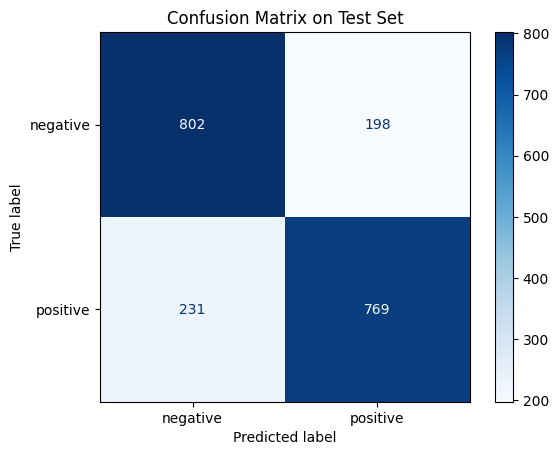

In [11]:
import matplotlib.pyplot as plt

clf = LogisticRegression(max_iter=2000, random_state=SEED)
clf.fit(X_train, y_train)

train_pred = clf.predict(X_train)
val_pred   = clf.predict(X_val)
test_pred  = clf.predict(X_test)

print("Training Accuracy   :", round(accuracy_score(y_train, train_pred), 4))
print("Validation Accuracy :", round(accuracy_score(y_val, val_pred), 4))
print("Test Accuracy       :", round(accuracy_score(y_test, test_pred), 4))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, target_names=["negative", "positive"]))

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix on Test Set")
plt.show()

In [12]:
test_probs = clf.predict_proba(X_test)[:, 1]
test_df = test_df.copy()
test_df["pred_label"] = test_pred
test_df["pred_sentiment"] = test_df["pred_label"].map({0: "negative", 1: "positive"})
test_df["confidence"] = np.where(test_df["pred_label"] == 1, test_probs, 1 - test_probs)
test_df["correct"] = test_df["label"] == test_df["pred_label"]

def guess_failure_reason(text):
    text_lower = text.lower()
    if "not" in text_lower or "never" in text_lower or "hardly" in text_lower:
        return "Possible negation/context failure."
    if "but" in text_lower or "although" in text_lower or "however" in text_lower:
        return "Mixed sentiment: the review may contain both positive and negative cues."
    if "!" in text_lower or "?" in text_lower:
        return "Strong emphasis or tone may not be captured by average embeddings."
    if "worst" in text_lower and "best" in text_lower:
        return "Conflicting strong sentiment words may confuse the model."
    return "Likely a subtle context, sarcasm, or long-range meaning failure."

print("5 Correctly Classified Reviews\n" + "=" * 80)
correct_examples = test_df[test_df["correct"]].sort_values("confidence", ascending=False).head(5)

for _, row in correct_examples.iterrows():
    short_review = row["review"][:350].replace("\n", " ")
    print(f"True: {row['sentiment']:<8} | Predicted: {row['pred_sentiment']:<8} | Confidence: {row['confidence']:.3f}")
    print("Review:", short_review + ("..." if len(row["review"]) > 350 else ""))
    print()

print("\n5 Incorrectly Classified Reviews\n" + "=" * 80)
incorrect_examples = test_df[~test_df["correct"]].sort_values("confidence", ascending=False).head(5)

for _, row in incorrect_examples.iterrows():
    short_review = row["review"][:350].replace("\n", " ")
    print(f"True: {row['sentiment']:<8} | Predicted: {row['pred_sentiment']:<8} | Confidence: {row['confidence']:.3f}")
    print("Review:", short_review + ("..." if len(row["review"]) > 350 else ""))
    print("Why it may have failed:", guess_failure_reason(row["review"]))
    print()



5 Correctly Classified Reviews
True: positive | Predicted: positive | Confidence: 1.000
Review: A surprisingly beautiful movie. Beautifully conceived, beautifully directed, beautifully acted, beautifully acted and most beautifully photographed.....the cinematography is nothing short of splendid. It is a war movie but is epic in it's scope and blends romance, tragedy and comedy into a story that is as harrowing as it is provoking.

True: positive | Predicted: positive | Confidence: 0.999
Review: Its the best movie I have seen in 2000, it has the beautiful and talented Natalie Portman in it. It has a great storyline, cast and soundtrack. I enjoyed it very much. 10 out of 10

True: positive | Predicted: positive | Confidence: 0.998
Review: "Boogie Nights" is a masterpiece it tells a great story with flair an great direction from a very talented director. This film features a cast which turn in outstanding performances. Though the subject matter is very controversial but it is handled with